In [3]:
import pandas as pd
import numpy as np
import random
import os
import argparse
import json
import torch
import pickle
import matplotlib.pyplot as plt
from attrdict import AttrDict
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from transformers import DistilBertModel, DistilBertTokenizer, DistilBertConfig, DistilBertForSequenceClassification
from transformers import AdamW, get_linear_schedule_with_warmup
from torchmetrics import R2Score

In [4]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="3"

In [5]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
model_path = os.path.join(default_path, '../models')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
config_file = "bert-base.json"

In [6]:
X_train = pd.read_csv(os.path.join(data_path, 'emodep_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, 'emodep_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, 'emodep_test.csv'))

In [7]:
X_train = X_train[['author', 'text', 'type', 'criteria']]
X_dev = X_dev[['author', 'text', 'type', 'criteria']]
X_test = X_test[['author', 'text', 'type', 'criteria']]

X_train.columns = ['author', 'text', 'type', 'label']
X_dev.columns = ['author', 'text', 'type', 'label']
X_test.columns = ['author', 'text', 'type', 'label']

In [8]:
model_name = 'distilbert-base-uncased'

In [9]:
tokenizer = DistilBertTokenizer.from_pretrained(model_name, model_max_length=128)
config = DistilBertConfig.from_pretrained(model_name, num_labels=9, output_hidden_states=True, output_attentions=True)
model = DistilBertForSequenceClassification.from_pretrained(model_name, config=config)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'pre_classifier.bias', 'classifier.weight', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [11]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [12]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
training_config.config_path = config_path
training_config.log_path = log_path
training_config.data_path = data_path
training_config.model_path = model_path 
training_config.pad = 'max_length'
training_config.num_epochs  = 5

In [13]:
model.to(training_config.device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
       

In [14]:
class DSMDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file

    def __len__(self):
        return len(self.data.label)

    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)

    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [15]:
class DSMProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer
        self.max_len = config.max_position_embeddings
        self.pad = training_config['pad']
        self.batch_size = training_config['train_batch_size']
        self.truncation = truncation

    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text,
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )

        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1]
            except:
                inputs['label'] = 0
            features.append(inputs)

        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        # all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        # dataset = TensorDataset(all_input_ids, all_attention_mask, all_token_type_ids, all_labels)
        dataset = TensorDataset(all_input_ids, all_attention_mask, all_labels)
        return dataset

    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)

    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [17]:
training_config['seed']

42

In [18]:
class DSMTrainer():
    def __init__(self, config, training_config, model, train_dataloader, eval_dataloader):
        self.config = config
        self.training_config = training_config
        self.model = model
        self.train_dataloader = train_dataloader
        self.eval_dataloader = eval_dataloader

    def set_seed(self):
        random.seed(self.training_config['seed'])
        np.random.seed(self.training_config['seed'])
        torch.manual_seed(self.training_config['seed'])
        if not self.training_config['no_cuda'] and torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.training_config['seed'])

    def train(self):
        train_acc_list = []; eval_acc_list = []
        train_loss_list = []; eval_loss_list = []
        # eval_acc_step = []; eval_loss_step = []
        # train_acc_step = []; train_loss_step = []
        nb_eval_steps = 0
        best_loss = 9999; best_epoch = 0
        t_total = len(self.train_dataloader) // self.training_config['gradient_accumulation_steps'] * self.training_config['num_epochs']

        optimizer = AdamW(self.model.parameters(), lr=self.training_config['learning_rate'], eps=self.training_config['adam_epsilon'])
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(t_total * self.training_config['warmup_proportion']), \
                                                    num_training_steps=t_total)

        self.model.zero_grad()
        for epoch in range(int(self.training_config['num_epochs'])):
            train_acc = 0.0; eval_acc = 0.0
            train_loss = 0.0; eval_loss = 0.0

            for step, batch in enumerate(self.train_dataloader):
                self.model.train()
                batch = tuple(t.to(self.training_config['device']) for t in batch)
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    # "token_type_ids": batch[2],
                    "labels": batch[2]
                }
                outputs = self.model(**inputs)
                criterion = nn.CrossEntropyLoss()
                # loss = outputs[0]
                # y_pred = torch.max(outputs[1], 1)[1]
                y_pred = outputs[1]
                y_true = batch[2]
                # y_true = torch.tensor([float(t) for t in y_true]).to(self.training_config.device)
                loss = criterion(y_pred, y_true)
                # print(outputs[0], outputs[1], batch[3])
                loss.backward()
                train_loss += loss.item()
                train_acc += self.calc_accuracy(outputs[1], batch[2])

                optimizer.step()
                scheduler.step()
                self.model.zero_grad()

            train_acc = train_acc / (step + 1)
            train_loss = train_loss / (step + 1)
            print(f'epoch: {epoch}, train_loss: {train_loss}')
            train_acc_list.append(train_acc)
            train_loss_list.append(train_loss)

            for step2, batch2 in enumerate(self.eval_dataloader):
                self.model.eval()
                batch2 = tuple(t.to(self.training_config['device']) for t in batch2)

                with torch.no_grad():
                    inputs = {
                        "input_ids": batch2[0],
                        "attention_mask": batch2[1],
                        # "token_type_ids": batch2[2],
                        "labels": batch2[2]
                    }
                    outputs = self.model(**inputs)
                    tmp_eval_loss, logits = outputs[:2]
                    loss2 = criterion(logits, batch2[2])
                    eval_loss += loss2.item()
                    eval_acc += self.calc_accuracy(outputs[1], batch2[2])
            eval_loss = eval_loss / (step2 + 1)
            eval_acc = eval_acc / (step2 + 1)
            eval_acc_list.append(eval_acc)
            eval_loss_list.append(eval_loss)
            print(f'epoch: {epoch}, eval_loss: {eval_loss}')

        self.save_model(os.path.join(self.training_config['model_path'], f'distil_emodep_e5.pt'))
        self.save_log(train_acc_list, train_loss_list, eval_acc_list, eval_loss_list, epoch)
        return train_acc_list, train_loss_list, eval_acc_list, eval_loss_list

    def calc_accuracy(self, X,Y):
        max_vals, max_indices = torch.max(X, 1)
        train_acc = (max_indices == Y).sum().data.cpu().numpy()/max_indices.size()[0]
        return train_acc

    def compute_metrics(self, labels, preds):
        assert len(preds) == len(labels)
        acc = (labels == preds).mean()
        return {"acc": acc}

    def save_log(self, train_acc, train_loss, eval_acc, eval_loss, epoch):
        with open(os.path.join(self.training_config['log_path'], f'distil_train_{epoch}_acc.pickle'), 'wb') as f:
            pickle.dump(train_acc, f, pickle.HIGHEST_PROTOCOL)

        with open(os.path.join(self.training_config['log_path'], f'distil_train_{epoch}_loss.pickle'), 'wb') as f:
            pickle.dump(train_loss, f, pickle.HIGHEST_PROTOCOL)

        with open(os.path.join(self.training_config['log_path'], f'distil_eval_{epoch}_acc.pickle'), 'wb') as f:
            pickle.dump(eval_acc, f, pickle.HIGHEST_PROTOCOL)

        with open(os.path.join(self.training_config['log_path'], f'distil_eval_{epoch}_loss.pickle'), 'wb') as f:
            pickle.dump(eval_loss, f, pickle.HIGHEST_PROTOCOL)

    def save_model(self, model_name):
        torch.save(self.model.state_dict(), model_name)

In [19]:
dsm_processor = DSMProcessor(config, training_config, tokenizer)

In [20]:
train_file = DSMDataset(X_train)
val_file = DSMDataset(X_dev)
test_file = DSMDataset(X_test)

In [21]:
train_dataset = dsm_processor.convert_data(train_file)
val_dataset = dsm_processor.convert_data(val_file)
test_dataset = dsm_processor.convert_data(test_file)

In [22]:
train_sampler = dsm_processor.shuffle_data(train_dataset, 'train')
val_sampler = dsm_processor.shuffle_data(val_dataset, 'eval')
test_sampler = dsm_processor.shuffle_data(test_dataset, 'test')

In [23]:
train_dataloader = dsm_processor.load_data(train_dataset, train_sampler)
val_dataloader = dsm_processor.load_data(val_dataset, val_sampler)
test_dataloader = dsm_processor.load_data(test_dataset, test_sampler)

In [24]:
bws_trainer = DSMTrainer(config, training_config, model, train_dataloader, val_dataloader)

In [25]:
train_acc, train_loss, eval_acc, eval_loss = bws_trainer.train()

/home/pbl1/anaconda3/envs/aaai/lib/python3.8/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


epoch: 0, train_loss: 0.12898108478154213
epoch: 0, eval_loss: 0.09672596480400077
epoch: 1, train_loss: 0.10040374247302401
epoch: 1, eval_loss: 0.09742470176628669
epoch: 2, train_loss: 0.09432205185676826
epoch: 2, eval_loss: 0.08964637746923657
epoch: 3, train_loss: 0.08954703661128725
epoch: 3, eval_loss: 0.08736575016693991
epoch: 4, train_loss: 0.084255284014769
epoch: 4, eval_loss: 0.08807790217077723


In [34]:
class BertClsTester():
    def __init__(self, training_config, model):
        self.training_config = training_config
        self.model = model

    def get_label(self, test_dataloader, test_type):
        '''
        test_type: 0  -> Test dataset
        test_type: 1  -> Test sentence
        '''
        preds = []
        labels = []

        for batch in test_dataloader:
            self.model.eval()
            batch = tuple(t.to(self.training_config.device) for t in batch)   # args.device: cuda
            with torch.no_grad():
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    # "token_type_ids": batch[2],
                    "labels": batch[2]
                }
                outputs = self.model(**inputs)
                # print(outputs)
                _ , logits = outputs[:2]    # loss, logits
                pred = logits.detach().cpu().numpy()
                if test_type == 0:
                    preds.extend(np.argmax(pred, axis=1))
                elif test_type == 1:
                    preds.append(np.argmax(pred))
            label = inputs["labels"].detach().cpu().numpy()
            labels.extend(label)
        return preds, labels

In [35]:
dsm_tester = BertClsTester(training_config, model)

In [36]:
import time

start2 = time.time()
dsm_pred, dsm_true = dsm_tester.get_label(test_dataloader, 0)
print(f'dsm predict time: {round(time.time() - start2, 3)}')

dsm predict time: 22.974


In [37]:
from torchmetrics.classification import F1Score, MulticlassPrecision, MulticlassRecall, MulticlassSpecificity

f1 = F1Score(task="multiclass", num_classes=10)
precision = MulticlassPrecision(num_classes=10)
recall = MulticlassRecall(num_classes=10)
specificity = MulticlassSpecificity(num_classes=10)

print(f'dsm precision: {precision(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'dsm recall: {recall(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'dsm specificity: {specificity(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'dsm f1-score: {f1(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')

dsm precision: 0.9090654850006104
dsm recall: 0.9183595776557922
dsm specificity: 0.9929563999176025
dsm f1-score: 0.9514158964157104


In [38]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [39]:
criterion = RMSELoss
loss = criterion(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))
loss

tensor(1.0807)

In [40]:
r2score = R2Score()
r2score(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))

tensor(0.8764)

In [41]:
from sklearn.preprocessing import label_binarize 

dsm_true = label_binarize(dsm_true, classes=list(range(9)))
dsm_pred = label_binarize(dsm_pred, classes=list(range(9)))

In [42]:
from sklearn.metrics import roc_curve, auc

n_classes = 9
fpr = dict()
tpr = dict()
roc_auc = dict() 

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(dsm_true[:,i], dsm_pred[:,i]) 
    roc_auc[i] = auc(fpr[i], tpr[i])

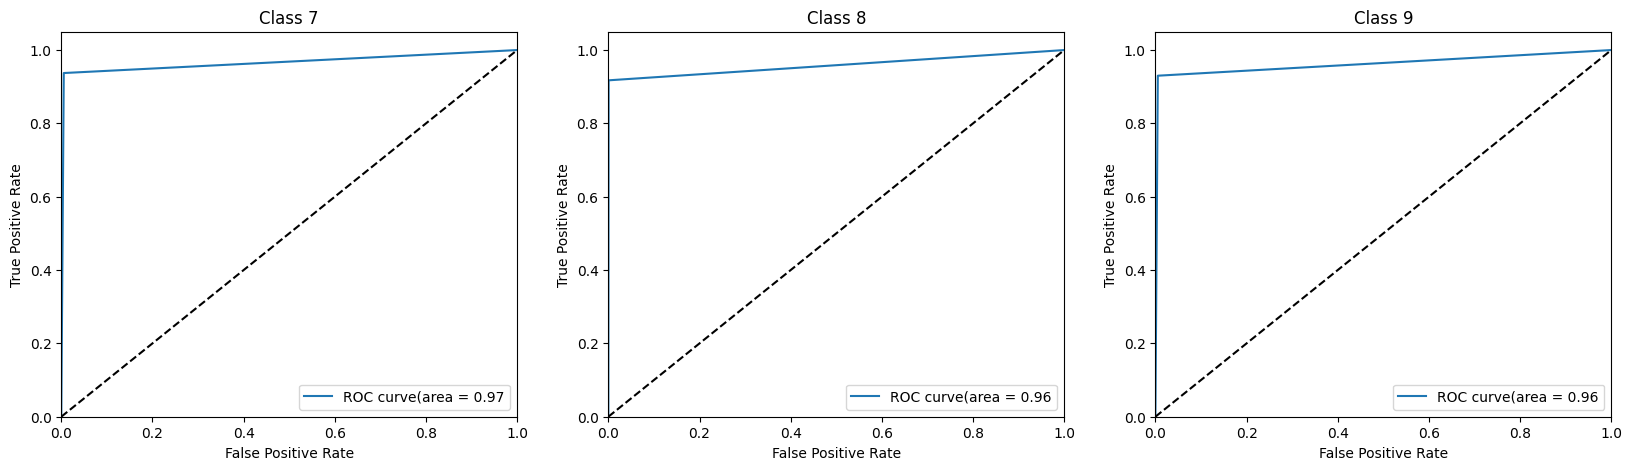

In [50]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(20, 5))
val = 0

for idx, i in enumerate(range(n_classes)):
    if idx == 6 or idx == 7 or idx == 8: 
        plt.subplot(131+val) 
        plt.plot(fpr[i], tpr[i], label = f'ROC curve(area = {round(roc_auc[i], 2)}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate') 
        plt.ylabel('True Positive Rate')
        plt.title(f'Class {idx + 1}')
        plt.legend(loc='lower right')
        val += 1
plt.show()